In [1]:
# Official packages
import os
import copy
import math
import re
import time

from pprint import pprint
from itertools import chain

# Third-party packages
import numpy as np
import scipy

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm


import pyopencl as cl
#for item in cl.get_platforms():
#    print(item.get_devices())

import pynufft
device_list = pynufft.helper.device_list()
for item in device_list:
    print(item)
    
# In-house packages
from BrukerPV360 import BrukerPV360Exp


def normalize_array(arr:np.array):
    return arr/np.max(np.abs(arr))

No OpenCL device found. Check your pyopencl installation.
('cuda', 0, 0, <reikna.cluda.cuda.Platform object at 0x7f01c35df650>, <reikna.cluda.cuda.Device object at 0x7f01c1cfd760>, <reikna.cluda.cuda.Thread object at 0x7f01c1c9a030>, 32)


(2646,)


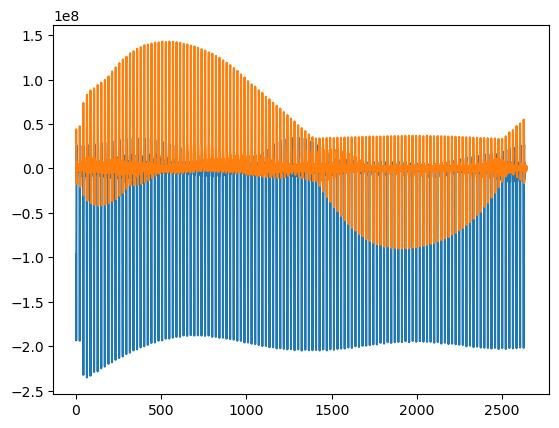

(126, 21)


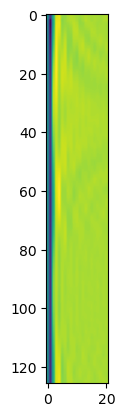

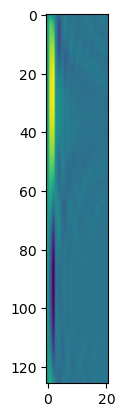

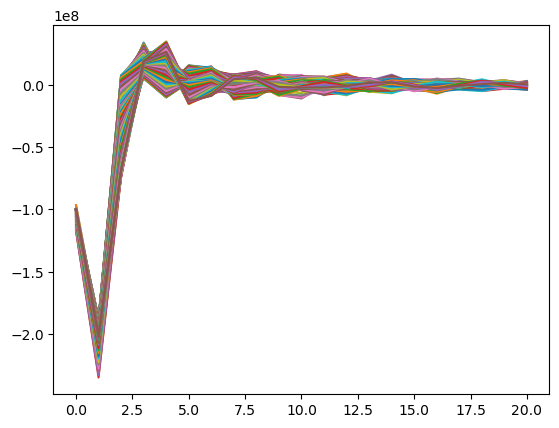

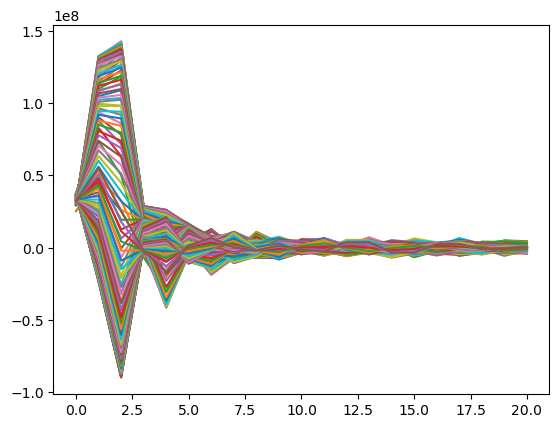

In [2]:
raw_path = "TestData/BrukerPV360/UTE2d"

a = BrukerPV360Exp(raw_path, is_verbose=False)

FID = a.dataset['DATA']['rawdata'][0]

print(np.shape(FID))

plt.figure()
plt.plot(np.real(FID))
plt.plot(np.imag(FID))
plt.show()

NPro = a.dataset['PARAM']['method'][0]['NPro']

FID_2d = np.reshape(FID, [NPro, -1])
print(np.shape(FID_2d))

plt.figure()
plt.imshow(np.real(FID_2d))
plt.show()
plt.figure()
plt.imshow(np.imag(FID_2d))
plt.show()

plt.figure()
for ro in FID_2d:
    plt.plot(np.real(ro))
plt.show()

plt.figure()
for ro in FID_2d:
    plt.plot(np.imag(ro))
plt.show()

2.0 100.0


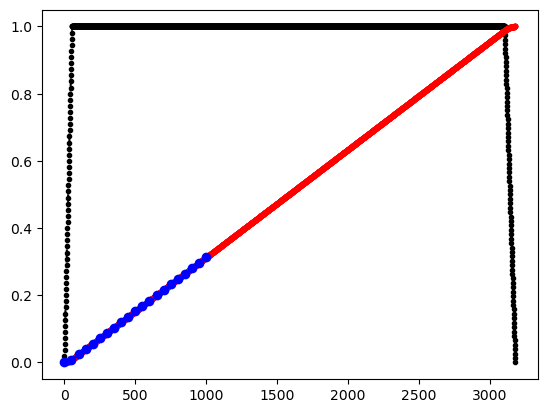

In [3]:
radial = (a.dataset['PARAM']['method'][0]['GradShape2'])
traj_radial = normalize_array(np.cumsum(radial))

gradRes_us = a.dataset['PARAM']['method'][0]['GradRes'] * 1000
roRes_us = 1e6/a.dataset['PARAM']['method'][0]['PVM_EffSWh']

print(gradRes_us, roRes_us)
idx = list(range(len(traj_radial)))[::int(roRes_us/gradRes_us)][:np.shape(FID_2d)[1]]
traj_cal = traj_radial[::int(roRes_us/gradRes_us)][:np.shape(FID_2d)[1]]


plt.figure()
plt.plot(radial, c= "black", marker='.', linestyle=':')
plt.plot(traj_radial, c= "red", marker='.', linestyle=':')
plt.plot(idx,traj_cal, c= "blue", marker='o', linestyle=':')
plt.show()


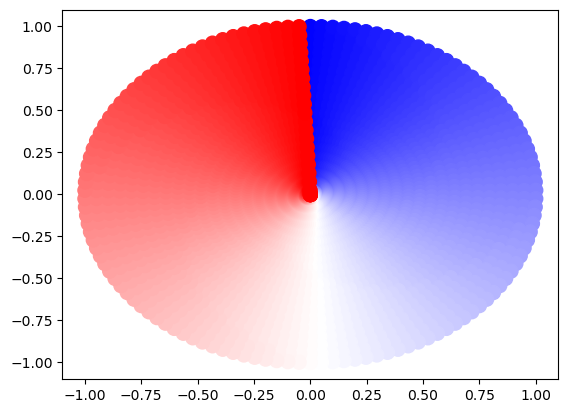

In [4]:
om = []
for i in range(NPro):
    om.append(traj_cal * np.exp(-(i/NPro-0.25)*1j*2*np.pi))
om = np.asarray(om).flatten()


rad_traj = np.asarray([[x.real,x.imag] for x in om]) 
rad_traj = rad_traj/np.max(np.abs(rad_traj))

plt.figure()
plt.scatter(rad_traj[:,0], rad_traj[:,1], c=(range(len(om))), s=100, cmap='bwr')
plt.show()


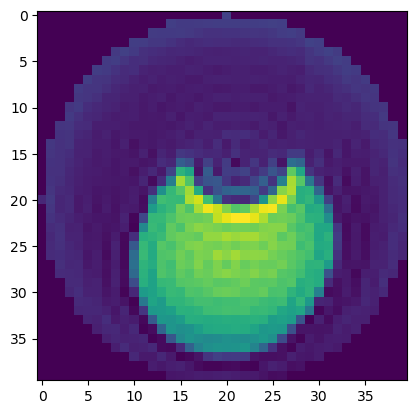

In [5]:
bruker_data = a.dataset['DATA']['2dseq']

img_shape = [int(x) for x in a.dataset['PARAM']['method'][0]['PVM_Matrix']]

NR = a.dataset['PARAM']['method'][0]['PVM_NRepetitions']

bruker_data = np.reshape(bruker_data, img_shape)
plt.figure()
plt.imshow(bruker_data, cmap=cm.viridis)
plt.show()


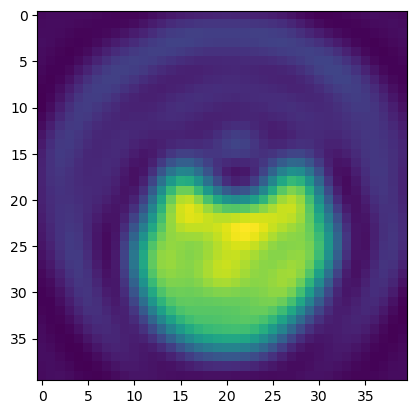

In [6]:
Nd = tuple(img_shape)  # image size
Kd = tuple([4*x for x in img_shape])  # k-space size
Jd = (6, 6)  # interpolation size

spiralObj = pynufft.NUFFT( )
spiralObj.plan(rad_traj, Nd, Kd, Jd)

bruker_data = np.reshape(bruker_data, img_shape)
y_cal = spiralObj.forward(bruker_data)
recon = spiralObj.solve(y_cal, solver='lgmres', maxiter=500)
plt.figure()
plt.imshow(recon.real, cmap=cm.viridis)
plt.show()


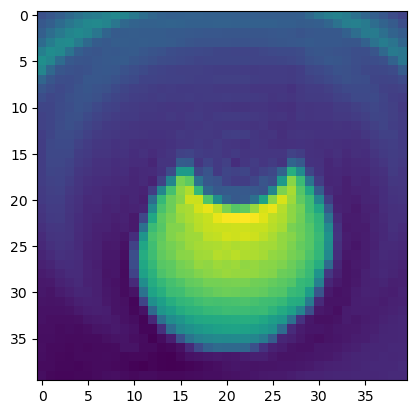

In [7]:
Nd = tuple(img_shape)  # image size
Kd = tuple([8*x for x in img_shape])  # k-space size
Jd = (6, 6)  # interpolation size

spiralObj = pynufft.NUFFT()
spiralObj.plan(rad_traj*np.pi, Nd, Kd, Jd)


recon = spiralObj.solve(np.roll(FID, 0), solver='bicgstab', maxiter=500)
plt.figure()
plt.imshow(np.abs(recon), cmap=cm.viridis)
plt.show()


(281358,)


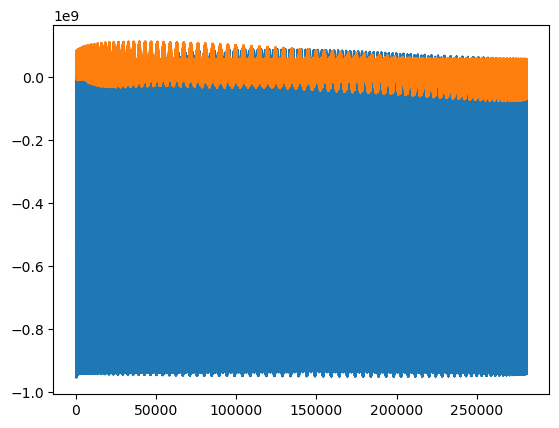

(9702, 29)


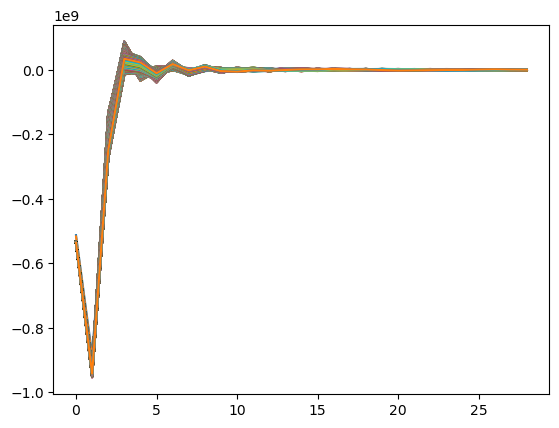

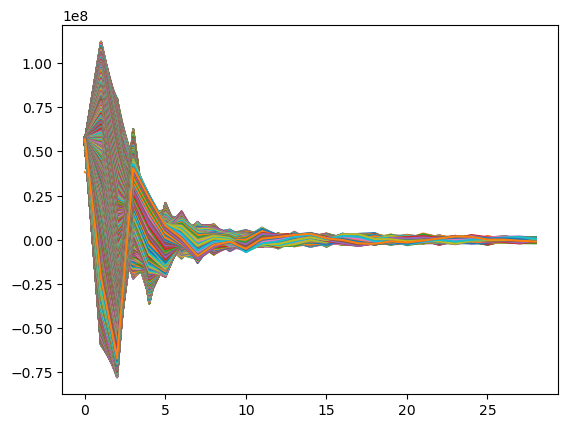

In [8]:
raw_path = "TestData/BrukerPV360/UTE3d"

a = BrukerPV360Exp(raw_path, is_verbose=False)

FID = a.dataset['DATA']['rawdata'][0]

print(np.shape(FID))

plt.figure()
plt.plot(np.real(FID))
plt.plot(np.imag(FID))
plt.show()

NPro = a.dataset['PARAM']['method'][0]['NPro']

FID_2d = np.reshape(FID, [NPro, -1])
print(np.shape(FID_2d))

"""
plt.figure()
plt.imshow(np.real(FID_2d))
plt.show()
plt.figure()
plt.imshow(np.imag(FID_2d))
plt.show()
"""

plt.figure()
for ro in FID_2d:
    plt.plot(np.real(ro))
plt.show()

plt.figure()
for ro in FID_2d:
    plt.plot(np.imag(ro))
plt.show()

5.0 100.0


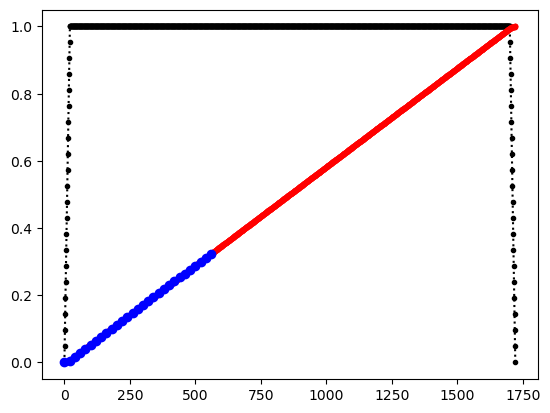

In [9]:
radial = (a.dataset['PARAM']['method'][0]['GradShape1'])
traj_radial = normalize_array(np.cumsum(radial))

gradRes_us = a.dataset['PARAM']['method'][0]['GradRes'] * 1000
roRes_us = 1e6/a.dataset['PARAM']['method'][0]['PVM_EffSWh']

print(gradRes_us, roRes_us)
idx = list(range(len(traj_radial)))[::int(roRes_us/gradRes_us)][:np.shape(FID_2d)[1]]
traj_cal = traj_radial[::int(roRes_us/gradRes_us)][:np.shape(FID_2d)[1]]


plt.figure()
plt.plot(radial, c= "black", marker='.', linestyle=':')
plt.plot(traj_radial, c= "red", marker='.', linestyle='-')
plt.plot(idx,traj_cal, c= "blue", marker='o', linestyle='--')
plt.show()

In [10]:
size = a.dataset['PARAM']['method'][0]['PVM_EncMatrix'][0]
ProUndersampling = a.dataset['PARAM']['method'][0]['ProUndersampling']
n_theta = (int) ((np.pi * size)/(2*ProUndersampling));
n_phi = (int) (np.pi*size*np.sin(np.pi/n_theta));

print(size, ProUndersampling,n_theta,n_phi)

56.0 1 87 6


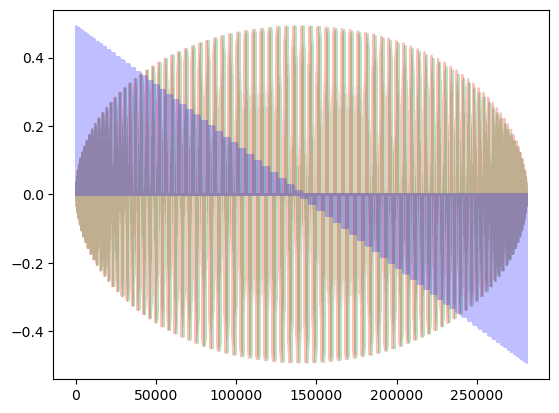

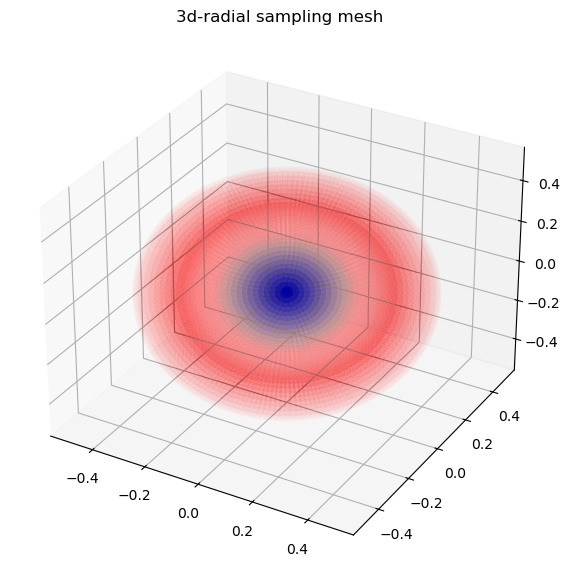

In [11]:
traj_K3d_path = "TestData/BrukerPV360/UTE3d/traj"
traj_K3d = np.fromfile(traj_K3d_path, dtype='float64')


traj_K3d = np.reshape(traj_K3d,[-1,3])

plt.figure()
plt.plot(traj_K3d[:,0], color='red', alpha=.25)
plt.plot(traj_K3d[:,1], color='green', alpha=.25)
plt.plot(traj_K3d[:,2], color='blue', alpha=.25)
plt.show()

fig = plt.figure(figsize = (10, 7))
ax = plt.axes(projection ="3d")

traj_K3d_norm = np.linalg.norm(traj_K3d, ord=2, axis=1)

ax.scatter3D(traj_K3d[:,0], traj_K3d[:,1], traj_K3d[:,2], c = traj_K3d_norm, cmap='bwr', alpha=.002)
plt.title("3d-radial sampling mesh")
 
# show plot
plt.show()



[56, 56, 56]


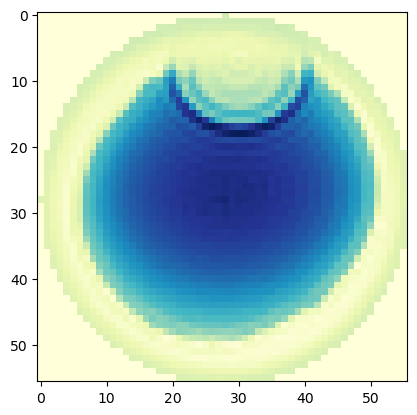

In [12]:
bruker_data = a.dataset['DATA']['2dseq']

img_shape = [int(x) for x in a.dataset['PARAM']['method'][0]['PVM_Matrix']]
print(img_shape)
NR = a.dataset['PARAM']['method'][0]['PVM_NRepetitions']

bruker_data = np.reshape(bruker_data, img_shape)
plt.figure()
plt.imshow(bruker_data[int(img_shape[2]/2)], cmap=cm.YlGnBu)
plt.show()

In [13]:
Nd = tuple(img_shape)  # image size
Kd = tuple([8*x for x in img_shape])  # k-space size
Jd = (6, 6, 6)  # interpolation size

print(np.shape(FID),  np.shape(traj_K3d))
print(Nd, Kd, Jd)


spiralStackObj = pynufft.NUFFT( )
spiralStackObj.plan(traj_K3d, Nd, Kd, Jd)

time1 = time.time()
recon = spiralStackObj.solve(FID, solver='cg', maxiter=500)
time2 = time.time()
print(time2-time1)

# 224 sec on Dell laptop with 100% CPU occupation.


(281358,) (281358, 3)
(56, 56, 56) (448, 448, 448) (6, 6, 6)
395.1647114753723


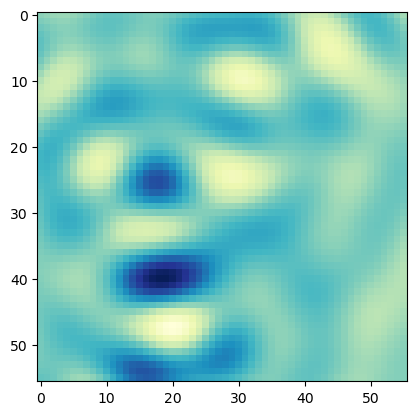

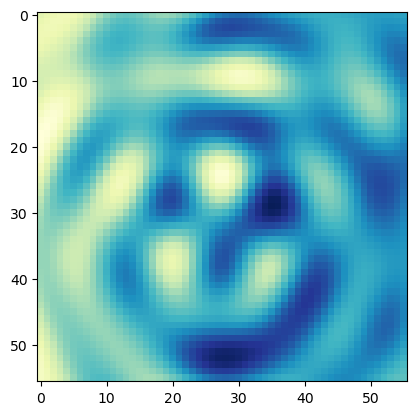

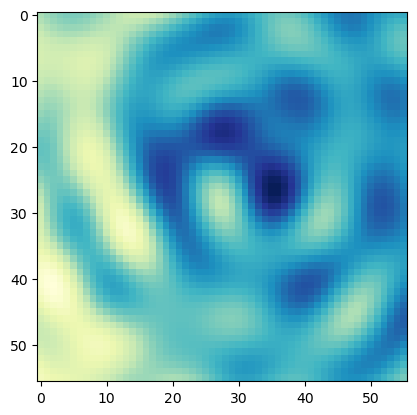

In [14]:
slice_idx = int(img_shape[2]/2)
plt.figure()
plt.imshow(np.abs(recon)[:,:,slice_idx], cmap=cm.YlGnBu)
plt.show()
plt.figure()
plt.imshow(np.abs(recon)[:,slice_idx,:], cmap=cm.YlGnBu)
plt.show()
plt.figure()
plt.imshow(np.abs(recon)[slice_idx,:,:], cmap=cm.YlGnBu)
plt.show()

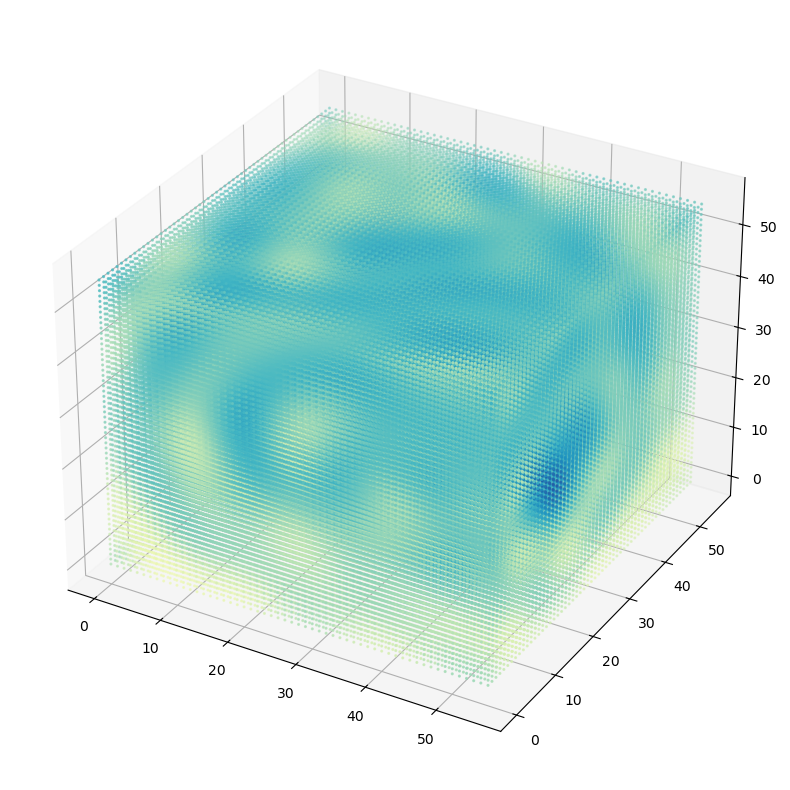

In [15]:
from itertools import product
from matplotlib import pyplot as plt
N = 56
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection="3d")
space = np.array([*product(range(N), range(N), range(N))]) # all possible triplets of numbers from 0 to N-1
volume = normalize_array(np.abs(recon))
ax.scatter(space[:,0], space[:,1], space[:,2], c=volume, s=volume*2, cmap='YlGnBu')